<a href="https://colab.research.google.com/github/Watagakari/TGNN_For_Traffic_Forcasting/blob/main/TGNN_Deep_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install torch-geometric-temporal
!pip install torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.0/210.0 kB 4.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.0/108.0 kB 4.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.3/102.3 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 27.3 MB/s eta 0:00:00
  Created wheel for torch-scatter: filename=torch_scatter-2.1.2-cp312-cp312-linux_x86_64.whl size=677289 sha256=7b09870b194bf94e0b5414685ba602c557a81fe959a2158af19ee77621021d68
  Stored in directory: /root/.cache/pip/wheels/84/20/50/44800723f57cd798630e77b3ec83bc80bd26a1e3dc3a672ef5
  Created wheel for torch-sparse: filename=torch_sparse-0.6.18-cp312-cp312-linux_x86_64.whl size=1261475 sha256=229566558e0a9115dc6cf3e28a29cfbe378a8a6d4d46507bc7e1eccb220a8524
  Stored in directory: /root/.cache/pip/wheels/71/fa/21/bd

In [ ]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import networkx as nx

In [ ]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from torch_geometric_temporal.signal import StaticGraphTemporalSignal
from torch_geometric_temporal.signal import temporal_signal_split
from torch_geometric_temporal.nn.recurrent import TGCN
from google.colab import drive

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
with open('/content/drive/MyDrive/metr-la-dataset/adj_METR-LA.pkl', 'rb') as f:
    adj_data = pickle.load(f, encoding='latin1')

print(type(adj_data))

<class 'list'>


In [ ]:
sensor_ids, sensor_id_to_ind, adj = adj_data
print(adj.shape)

(207, 207)


In [ ]:
traffic_df = pd.read_hdf('/content/drive/MyDrive/metr-la-dataset/METR-LA.h5')
print(traffic_df.shape)
traffic_df.head()

(34272, 207)


,773869,767541,767542,717447,717446,717445,773062,767620,737529,717816,...,772167,769372,774204,769806,717590,717592,717595,772168,718141,769373
2012-03-01 00:00:00,64.375000,67.625000,67.125000,61.500000,66.875000,68.750000,65.125,67.125,59.625000,62.750000,...,45.625000,65.500,64.500000,66.428571,66.875,59.375000,69.000000,59.250000,69.000000,61.875
2012-03-01 00:05:00,62.666667,68.555556,65.444444,62.444444,64.444444,68.111111,65.000,65.000,57.444444,63.333333,...,50.666667,69.875,66.666667,58.555556,62.000,61.111111,64.444444,55.888889,68.444444,62.875
2012-03-01 00:10:00,64.000000,63.750000,60.000000,59.000000,66.500000,66.250000,64.500,64.250,63.875000,65.375000,...,44.125000,69.000,56.500000,59.250000,68.125,62.500000,65.625000,61.375000,69.857143,62.000
2012-03-01 00:15:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000,0.000,0.000000,0.000000,...,0.000000,0.000,0.000000,0.000000,0.000,0.000000,0.000000,0.000000,0.000000,0.000
2012-03-01 00:20:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000,0.000,0.000000,0.000000,...,0.000000,0.000,0.000000,0.000000,0.000,0.000000,0.000000,0.000000,0.000000,0.000


In [ ]:
traffic_values = traffic_df.values

print(traffic_values.shape)

(34272, 207)


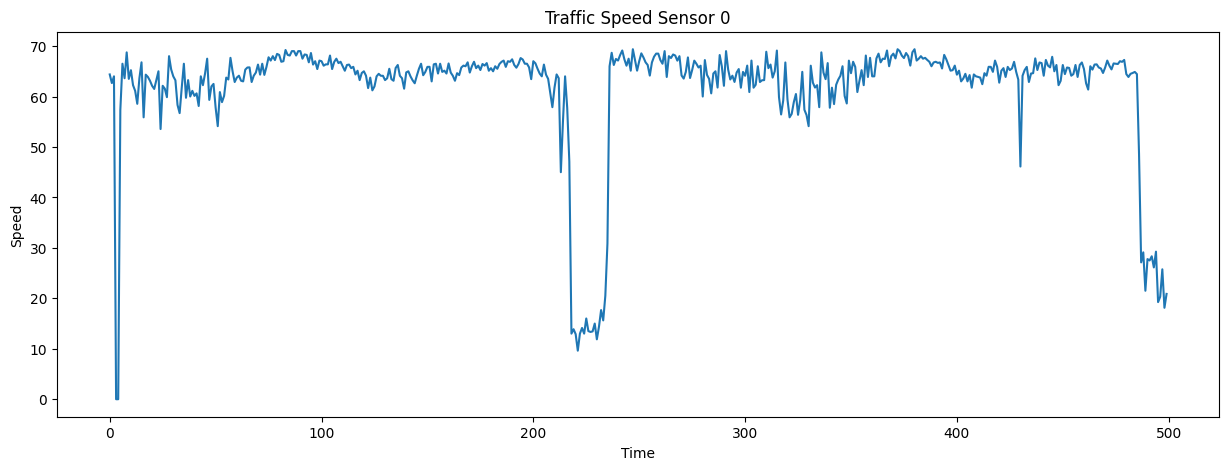

In [ ]:
plt.figure(figsize=(15,5))

plt.plot(traffic_values[:500, 0])

plt.title("Traffic Speed Sensor 0")
plt.xlabel("Time")
plt.ylabel("Speed")

plt.show()

In [ ]:
traffic_values[traffic_values == 0] = np.nan

In [ ]:
traffic_df_clean = pd.DataFrame(traffic_values)

traffic_df_clean = traffic_df_clean.interpolate(
    method='linear',
    axis=0
)

traffic_df_clean = traffic_df_clean.bfill()
traffic_df_clean = traffic_df_clean.ffill()

traffic_values = traffic_df_clean.values

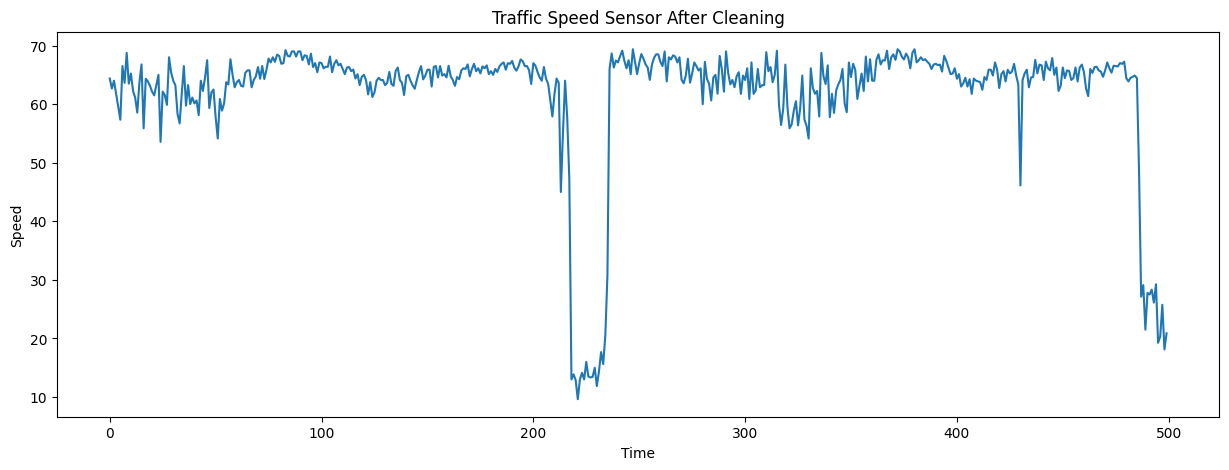

In [ ]:
plt.figure(figsize=(15,5))

plt.plot(traffic_values[:500, 0])

plt.title("Traffic Speed Sensor After Cleaning")
plt.xlabel("Time")
plt.ylabel("Speed")

plt.show()

In [ ]:
scaler = MinMaxScaler()

traffic_scaled = scaler.fit_transform(traffic_values)

In [ ]:
print(traffic_scaled)

[[0.91666667 0.95983087 0.95354578 ... 0.84191176 0.98450947 0.88151042]
 [0.89135802 0.97556965 0.92639138 ... 0.79248366 0.97590361 0.89609375]
 [0.91111111 0.89429175 0.83842011 ... 0.87316176 0.99778707 0.88333333]
 ...
 [0.95555556 0.82522903 0.99281867 ... 0.90196078 0.96041308 0.87199074]
 [0.95185185 0.86892178 0.93536804 ... 0.89705882 0.96708262 0.90520833]
 [0.92757202 0.94738078 0.94793537 ... 0.90522876 0.97934596 0.88009259]]


In [ ]:
print(traffic_values)

[[64.375      67.625      67.125      ... 59.25       69.
  61.875     ]
 [62.66666667 68.55555556 65.44444444 ... 55.88888889 68.44444444
  62.875     ]
 [64.         63.75       60.         ... 61.375      69.85714286
  62.        ]
 ...
 [67.         59.66666667 69.55555556 ... 63.33333333 67.44444444
  61.22222222]
 [66.75       62.25       66.         ... 63.         67.875
  63.5       ]
 [65.11111111 66.88888889 66.77777778 ... 63.55555556 68.66666667
  61.77777778]]


In [ ]:
sequence_length = 12

features = []
targets = []

for i in range(len(traffic_scaled) - sequence_length):

    x = traffic_scaled[i:i+sequence_length].T
    y = traffic_scaled[i+sequence_length]

    features.append(x)
    targets.append(y)

In [ ]:
print(features[0].shape)
print(targets[0].shape)

(207, 12)
(207,)


In [ ]:
edge_index = np.array(np.nonzero(adj))
edge_weight = adj[adj != 0]

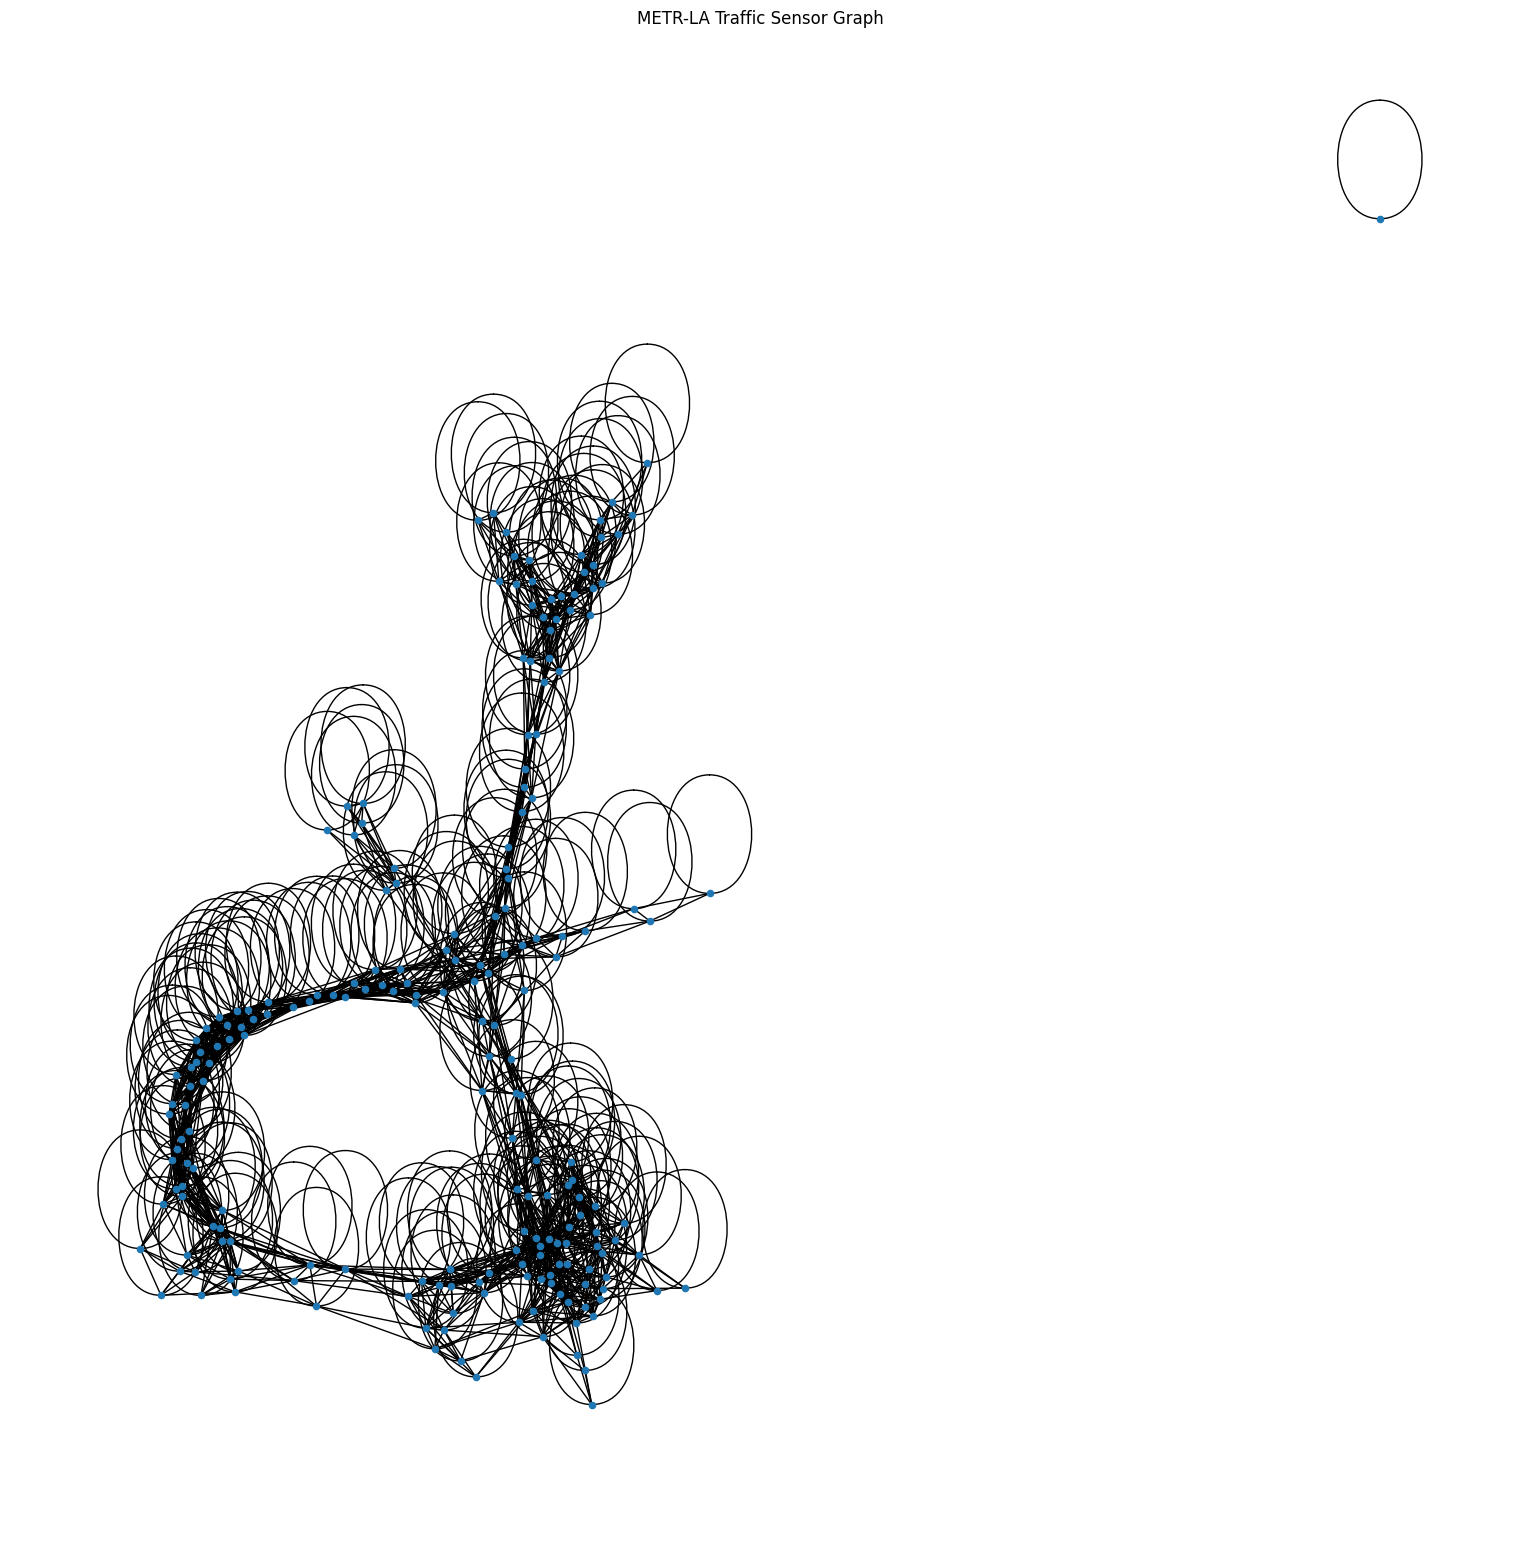

In [ ]:
G = nx.Graph()

for i in range(edge_index.shape[1]):

    source = edge_index[0, i]
    target = edge_index[1, i]

    G.add_edge(source, target)

plt.figure(figsize=(15,15))

nx.draw(
    G,
    node_size=20,
    with_labels=False
)

plt.title("METR-LA Traffic Sensor Graph")

plt.show()

In [ ]:
print(edge_index.shape)
print(edge_weight.shape)

(2, 1722)
(1722,)


In [ ]:
dataset = StaticGraphTemporalSignal(
    edge_index=edge_index,
    edge_weight=None,
    features=features,
    targets=targets
)

In [ ]:
train_dataset, temp_dataset = temporal_signal_split(
    dataset,
    train_ratio=0.7
)

val_dataset, test_dataset = temporal_signal_split(
    temp_dataset,
    train_ratio=0.5
)

In [ ]:
class TemporalGNN(nn.Module):

    def __init__(self, node_features):

        super(TemporalGNN, self).__init__()

        self.tgnn = TGCN(
            in_channels=node_features,
            out_channels=32
        )

        self.linear = nn.Linear(32, 1)

    def forward(
        self,
        x,
        edge_index,
        edge_weight
    ):

        h = self.tgnn(
            x,
            edge_index,
            edge_weight
        )

        h = F.relu(h)

        h = self.linear(h)

        return h

In [ ]:
model = TemporalGNN(
    node_features=sequence_length
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.01
)

criterion = nn.MSELoss()

In [ ]:
device = torch.device(
    'cuda' if torch.cuda.is_available()
    else 'cpu'
)

model = model.to(device)

patience = 20
counter = 0

best_val_loss = float('inf')
min_delta = 0.0001

train_losses = []
val_losses = []

for epoch in range(50):

    model.train()

    train_loss = 0
    train_steps = 0

    for snapshot in train_dataset:

        x = torch.FloatTensor(snapshot.x).to(device)
        y = torch.FloatTensor(snapshot.y).to(device)

        edge_index_tensor = torch.LongTensor(
            snapshot.edge_index
        ).to(device)

        optimizer.zero_grad()

        y_hat = model(
            x,
            edge_index_tensor,
            None
        ).squeeze()

        loss = criterion(y_hat, y)

        loss.backward()

        optimizer.step()

        train_loss += loss.item()
        train_steps += 1

    avg_train_loss = train_loss / train_steps

    model.eval()

    val_loss = 0
    val_steps = 0

    with torch.no_grad():

        for snapshot in val_dataset:

            x = torch.FloatTensor(snapshot.x).to(device)
            y = torch.FloatTensor(snapshot.y).to(device)

            edge_index_tensor = torch.LongTensor(
                snapshot.edge_index
            ).to(device)

            y_hat = model(
                x,
                edge_index_tensor,
                None
            ).squeeze()

            loss = criterion(y_hat, y)

            val_loss += loss.item()
            val_steps += 1

    avg_val_loss = val_loss / val_steps

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    print(
        f'Epoch {epoch+1} | '
        f'Train Loss: {avg_train_loss:.4f} | '
        f'Val Loss: {avg_val_loss:.4f}'
    )

    if avg_val_loss < best_val_loss - min_delta:

        best_val_loss = avg_val_loss
        counter = 0

        torch.save(
            model.state_dict(),
            'best_model.pth'
        )

        print('Validation improved.')

    else:

        counter += 1

        print(
            f'EarlyStopping Counter: '
            f'{counter}/{patience}'
        )

        if counter >= patience:

            print('Early stopping triggered.')

            break

Epoch 1 | Train Loss: 0.0242 | Val Loss: 0.0240
Validation improved.
Epoch 2 | Train Loss: 0.0242 | Val Loss: 0.0240
EarlyStopping Counter: 1/20
Epoch 3 | Train Loss: 0.0242 | Val Loss: 0.0240
EarlyStopping Counter: 2/20
Epoch 4 | Train Loss: 0.0242 | Val Loss: 0.0240
EarlyStopping Counter: 3/20
Epoch 5 | Train Loss: 0.0242 | Val Loss: 0.0240
EarlyStopping Counter: 4/20
Epoch 6 | Train Loss: 0.0242 | Val Loss: 0.0240
EarlyStopping Counter: 5/20
Epoch 7 | Train Loss: 0.0242 | Val Loss: 0.0240
EarlyStopping Counter: 6/20
Epoch 8 | Train Loss: 0.0242 | Val Loss: 0.0240
EarlyStopping Counter: 7/20
Epoch 9 | Train Loss: 0.0242 | Val Loss: 0.0240
EarlyStopping Counter: 8/20
Epoch 10 | Train Loss: 0.0242 | Val Loss: 0.0240
EarlyStopping Counter: 9/20
Epoch 11 | Train Loss: 0.0242 | Val Loss: 0.0240
EarlyStopping Counter: 10/20
Epoch 12 | Train Loss: 0.0242 | Val Loss: 0.0240
EarlyStopping Counter: 11/20
Epoch 13 | Train Loss: 0.0242 | Val Loss: 0.0240
EarlyStopping Counter: 12/20
Epoch 14 | T

In [ ]:
model.load_state_dict(
    torch.load('best_model.pth')
)

<All keys matched successfully>

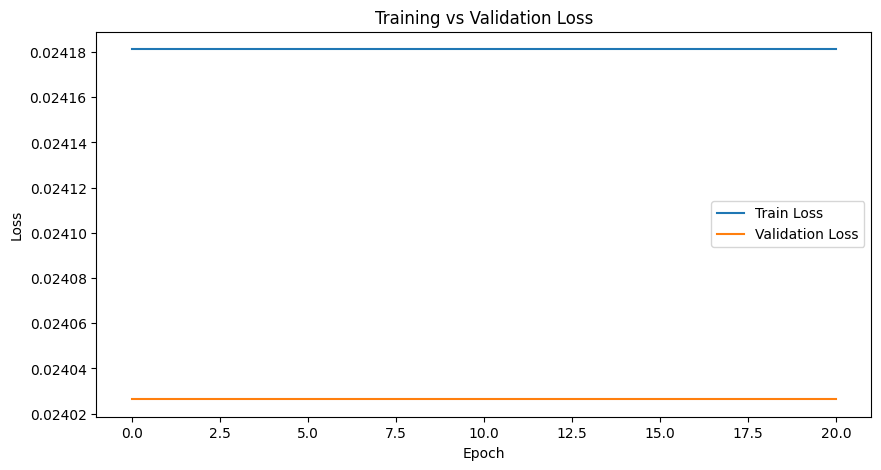

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.title('Training vs Validation Loss')

plt.legend()

plt.show()

In [ ]:

torch.save(model, '/content/drive/MyDrive/metr-la-dataset/entire_model.pth')

Load Model dan Model Testing


In [ ]:
model = torch.load(
    '/content/drive/MyDrive/metr-la-dataset/entire_model.pth',
    weights_only=False
)

In [ ]:
model.eval()

predictions = []
labels = []

with torch.no_grad():

    for snapshot in test_dataset:

        x = torch.FloatTensor(snapshot.x)
        y = torch.FloatTensor(snapshot.y)

        edge_index_tensor = torch.LongTensor(
            snapshot.edge_index
        )

        y_hat = model(
            x,
            edge_index_tensor,
            None
        ).squeeze()

        predictions.append(y_hat.numpy())
        labels.append(y.numpy())

In [ ]:
predictions = np.array(predictions)
labels = np.array(labels)

mae = mean_absolute_error(
    labels.flatten(),
    predictions.flatten()
)

rmse = np.sqrt(
    mean_squared_error(
        labels.flatten(),
        predictions.flatten()
    )
)

print("MAE  :", mae)
print("RMSE :", rmse)

MAE  : 0.11648079752922058
RMSE : 0.15977371866855147


In [ ]:
snapshot = next(iter(test_dataset))

In [ ]:
x = torch.FloatTensor(snapshot.x)
y = torch.FloatTensor(snapshot.y)

edge_index_tensor = torch.LongTensor(
    snapshot.edge_index
)

In [ ]:
with torch.no_grad():

    prediction = model(
        x,
        edge_index_tensor,
        None
    ).squeeze()

print(prediction)

tensor([0.8570, 0.8577, 0.8506, 0.8475, 0.8480, 0.8331, 0.8502, 0.8562, 0.8382,
        0.8460, 0.8581, 0.8588, 0.8550, 0.8588, 0.8573, 0.8545, 0.8575, 0.8450,
        0.8110, 0.8528, 0.8526, 0.7401, 0.8570, 0.7333, 0.8556, 0.7746, 0.8453,
        0.8587, 0.8555, 0.7685, 0.8580, 0.8470, 0.7946, 0.8546, 0.8494, 0.8325,
        0.8422, 0.8553, 0.8301, 0.8449, 0.8513, 0.8498, 0.8570, 0.8571, 0.8556,
        0.8539, 0.7790, 0.8391, 0.8551, 0.8569, 0.8302, 0.8065, 0.8353, 0.8547,
        0.8553, 0.8586, 0.8120, 0.8417, 0.8570, 0.8133, 0.8523, 0.8218, 0.8397,
        0.8523, 0.8284, 0.7822, 0.8001, 0.8578, 0.8576, 0.8488, 0.8527, 0.8574,
        0.8586, 0.8472, 0.8398, 0.8307, 0.8447, 0.8562, 0.8439, 0.8584, 0.8542,
        0.8517, 0.8573, 0.8432, 0.8546, 0.8589, 0.8212, 0.8468, 0.8571, 0.8527,
        0.8539, 0.8502, 0.8584, 0.8538, 0.8405, 0.8580, 0.8517, 0.8527, 0.8566,
        0.8383, 0.8530, 0.8480, 0.8567, 0.8582, 0.8095, 0.8543, 0.8486, 0.8460,
        0.8588, 0.7312, 0.8581, 0.8537, 

In [ ]:
prediction = prediction.cpu().numpy()
actual = y.cpu().numpy()

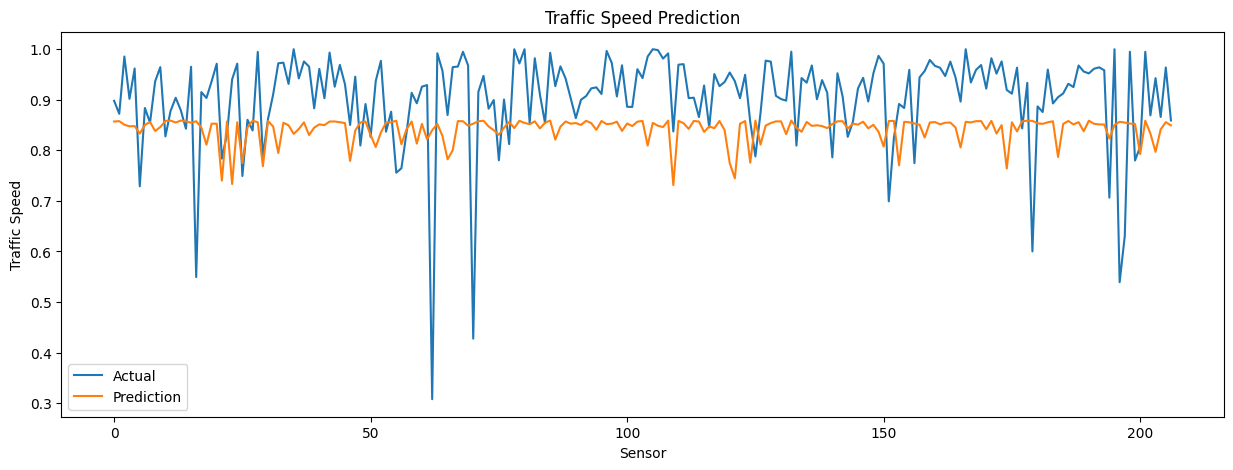

In [ ]:
plt.figure(figsize=(15,5))

plt.plot(
    actual[:207],
    label='Actual'
)

plt.plot(
    prediction[:207],
    label='Prediction'
)

plt.title('Traffic Speed Prediction')

plt.xlabel('Sensor')
plt.ylabel('Traffic Speed')

plt.legend()

plt.show()